# Decision Tree Classifier from Scratch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Mock Data Generation

In [3]:
def generate_multiclass_data(n_samples=300):
    X = np.random.randn(n_samples, 5)
    # Creating 3 classes based on feature combinations
    y = np.zeros(n_samples, dtype=int)
    y[X[:, 0] + X[:, 1] > 1] = 1
    y[X[:, 2] - X[:, 3] < -1] = 2
    
    columns = [f"Feature_{i+1}" for i in range(5)]
    df = pd.DataFrame(X, columns=columns)
    df['Target'] = y
    return df, X, y

df, X, y = generate_multiclass_data()
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Target
0,-2.491550,0.300736,-1.584044,-0.905644,2.025561,0
1,0.540467,1.000940,1.095184,-0.120796,-0.487027,1
2,-0.721572,-2.265066,0.261082,-0.393359,-0.667828,0
3,0.609241,0.754971,0.085352,1.673811,-1.342689,2
4,0.753703,-0.446864,-0.905099,0.518801,0.028668,2


In [7]:
np.bincount(y).argmax()

0

## 2. Implementation

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # Class label for leaf nodes

class DecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.n_classes = len(np.unique(y))
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        unique_labels = np.unique(y)
        
        if (depth >= self.max_depth or n_samples < self.min_samples_split or len(unique_labels) == 1):
            most_common = np.bincount(y).argmax()
            return Node(value=most_common)
        
        best_feat, best_thresh = self._best_split(X, y)
        if best_feat is None:
            return Node(value=np.bincount(y).argmax())
        
        left_idxs = X[:, best_feat] <= best_thresh
        right_idxs = ~left_idxs
        
        left = self._grow_tree(X[left_idxs], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs], y[right_idxs], depth + 1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)

    def _best_split(self, X, y):
        best_gini = 1.0
        split_idx, split_thresh = None, None
        
        for feat_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feat_idx])
            for thresh in thresholds:
                left_y = y[X[:, feat_idx] <= thresh]
                right_y = y[X[:, feat_idx] > thresh]
                
                if len(left_y) > 0 and len(right_y) > 0:
                    gini = self._calculate_gini(left_y, right_y)
                    if gini < best_gini:
                        best_gini = gini
                        split_idx = feat_idx
                        split_thresh = thresh
        return split_idx, split_thresh

    def _calculate_gini(self, left_y, right_y):
        def gini(sub_y):
            if len(sub_y) == 0: return 0
            probs = np.bincount(sub_y) / len(sub_y)
            return 1 - np.sum(probs**2)
        
        n = len(left_y) + len(right_y)
        return (len(left_y)/n) * gini(left_y) + (len(right_y)/n) * gini(right_y)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## 3. Training the Model

In [ ]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X, y)

y_pred = model.predict(X)
print(f"Accuracy: {np.mean(y == y_pred) * 100:.2f}%")

Accuracy: 96.00%


## 4. Visualization of Results

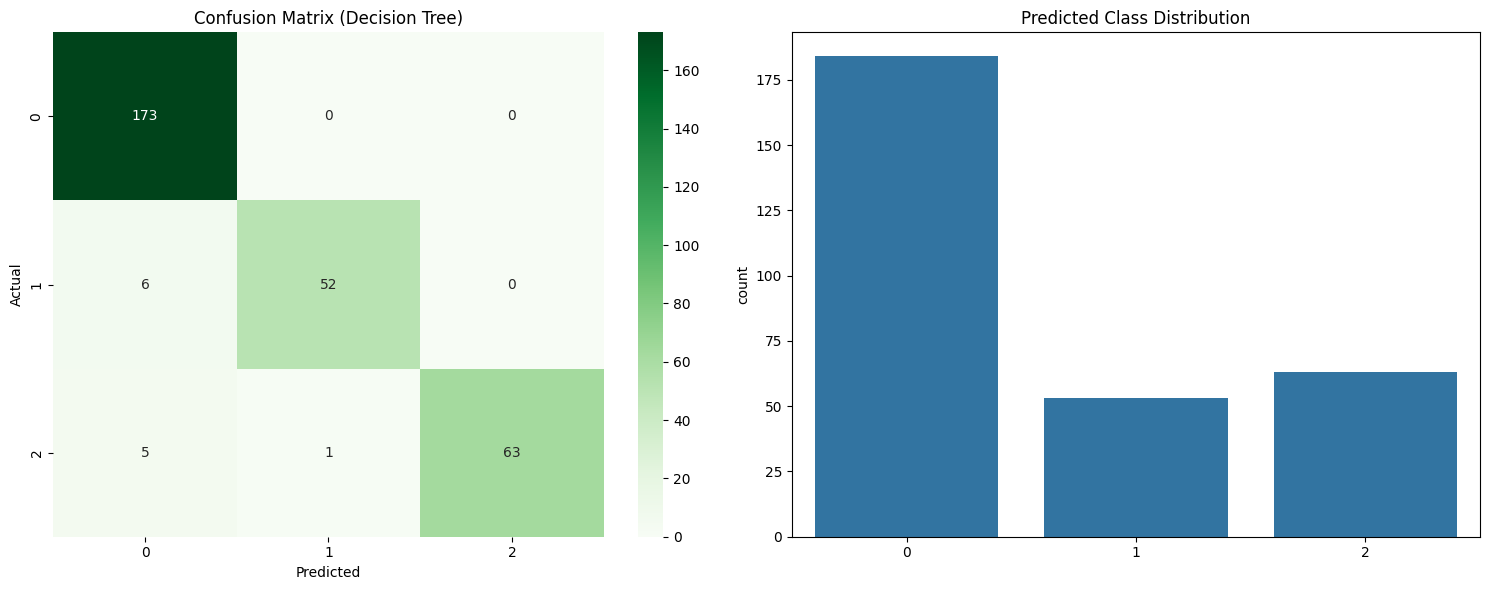

In [5]:
plt.figure(figsize=(15, 6))

# 1. Confusion Matrix
plt.subplot(1, 2, 1)
results_df = pd.DataFrame({'Actual': y, 'Predicted': y_pred})
matrix = pd.crosstab(results_df['Actual'], results_df['Predicted'])
sns.heatmap(matrix, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (Decision Tree)")

# 2. Class Distribution
plt.subplot(1, 2, 2)
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()